# RF across groups

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(dplyr)
quiet_library(stats)
quiet_library(qvalue)
quiet_library(dunn.test)
quiet_library(ggplot2)
quiet_library(rstatix)

Warning message:
“package ‘dunn.test’ was built under R version 4.3.3”


## Read in metadata

In [3]:
meta_uuid <- '32b8bb9c-4834-4e5c-9b3a-7939b3b7f057'

In [4]:
meta_file <- cacheFiles(list(meta_uuid))

meta <- read.csv(meta_file, 
                 header = T, stringsAsFactors = F)

nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

## Cross-sectional: HC1|NONC|CONV|ERA

In [5]:
# conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
#           'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
#           'SD1003', 'SD1007')

# outCols <- c('Status_Long')

In [6]:
# filter samples to baseline
meta_baseline <- meta %>% #filter(!is.na(Status_Xsec))%>% 
    filter(!(Status_Xsec=='early_RA' & Status_Long%in% c('conversion', 'pre')) &
          sample.sampleKitGuid != 'KT04113')%>% # remove duplicate CU1009 (post-conversion) entry to match other analyses
    distinct(subject.subjectGuid, .keep_all = TRUE)%>%
    mutate(status_converter = case_when(Status_Xsec=='at_risk' & Status_Long=='pre' ~ 'converter', 
                                        Status_Xsec=='at_risk' & is.na(Status_Long) ~ 'non_converter',
                                       TRUE ~ Status_Xsec)) %>% 
    mutate(Status=factor(recode(status_converter, 'ALTRA_healthy'='HC1', 
                                'non_converter'='NONC', 'converter'='CONV', 'early_RA'='ERA'
                               ), levels = c('HC1', 'NONC', 'CONV', 'ERA')),
          rfigm_result = if_else(rfigm_result==999, NA, rfigm_result))
           
    # filter(Status %in% c('ALTRA_healthy', 'non_converter', 'converter', 'early_RA'), # remove original at_risk distinction
    #        sample.sampleKitGuid != 'KT04113') # remove duplicate CU1009 (post-conversion) entry to match other analyses

In [7]:
meta_baseline %>% group_by(Status, Status_Xsec)%>%tally()
meta_baseline%>%filter(is.na(rfigm_result))

Status,Status_Xsec,n
<fct>,<chr>,<int>
HC1,ALTRA_healthy,38
NONC,at_risk,31
CONV,at_risk,14
ERA,early_RA,11


Status_Xsec,Status_Long,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,⋯,record_id...123,BMI,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,status_converter,Status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,⋯,<lgl>,<dbl>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>,<fct>
ALTRA_healthy,NA,KT02286,Flu Year 1 Stand-Alone,N/A - Flu-Series Timepoint Only,2022-08-01,0,SD1022,Female,1985,⋯,NA,31.60284,NA,NA,2,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT02298,Flu Year 1 Stand-Alone,N/A - Flu-Series Timepoint Only,2022-09-01,0,SD1026,Female,1965,⋯,NA,20.56127,NA,NA,NA,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04659,RA Year 4 Visit 1,N/A - on-going collection,2023-05-01,0,CU1100,Female,1978,⋯,NA,22.19201,NA,NA,NA,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04664,RA Year 4 Visit 1,N/A - on-going collection,2023-03-01,0,CU1097,Female,1957,⋯,NA,25.27089,NA,NA,7,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04671,RA Year 4 Visit 1,N/A - on-going collection,2023-05-01,0,CU1101,Female,1982,⋯,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04905,RA Year 4 Visit 1,N/A - on-going collection,2023-07-01,0,CU1104,Female,2000,⋯,NA,15.46422,NA,NA,6,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04908,RA Year 4 Visit 1,N/A - on-going collection,2023-07-01,0,CU1105,Female,1999,⋯,NA,21.26200,NA,NA,6,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04933,RA Year 4 Visit 1,N/A - on-going collection,2023-03-01,0,CU1098,Female,1969,⋯,NA,28.65839,NA,NA,6,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04937,RA Year 4 Visit 1,N/A - on-going collection,2023-04-01,0,CU1099,Female,1949,⋯,NA,28.90587,NA,NA,6,NA,NA,NA,ALTRA_healthy,HC1


## Visualizations

In [8]:
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision'

In [9]:
plotBoxplot <- function(df, y, int, ylab) {

    a <- df %>%
        filter(.data[[y]] != '999')

    ggplot(a, aes(x=Status, 
                  y=.data[[y]],
                  colour=Status)) + 
        geom_boxplot(outlier.shape = NA, lwd=0.5) + 
        geom_jitter(position = position_jitter(0.1), 
                    cex = 1.5) + 
        geom_hline(yintercept = int, 
                   linetype = 'dashed') + 
        scale_colour_manual( values = c('#4C8CBD', 
                                       '#FFCD70',
                                       '#FF540A', 
                                       '#840032')) + 
        labs(x = 'Status', 
             y = ylab) +
        theme_classic() + 
        theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
               legend.position = 'none',
               axis.text.y = element_text(size = 12, color='black'),
               axis.text.x = element_text(size = 12, color='black', angle = 45, vjust = 0.5, hjust=0.5), 
               axis.title.y = element_text(size = 12, color='black'), 
               axis.title.x = element_text(size = 12, color='black'))

}

#### RF-IgM

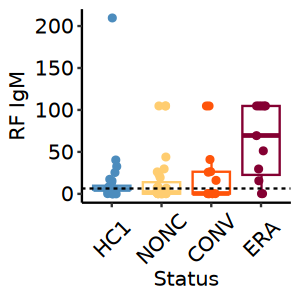

In [10]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5) # default 7x7

p <- plotBoxplot(meta_baseline, 'rfigm_result', 6.7, 'RF IgM')
p
ggsave(filename = file.path(fig_path, 'FigS1C_bottom_RFIgM.pdf'), 
       device = 'pdf', 
       width = 2.5, 
       height = 2.5, 
       units = 'in')

In [11]:
kruskal.test(rfigm_result ~ Status, 
             data = meta_baseline)


	Kruskal-Wallis rank sum test

data:  rfigm_result by Status
Kruskal-Wallis chi-squared = 10.403, df = 3, p-value = 0.01543


In [12]:
meta_baseline %>% dunn_test(rfigm_result~Status, 
          p.adjust.method  = 'BH')

,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rfigm_result,HC1,NONC,28,31,-1.0883684,0.276432520,0.414648780,ns
2,rfigm_result,HC1,CONV,28,14,-0.5775796,0.563547964,0.676257557,ns
3,rfigm_result,HC1,ERA,28,11,2.3164809,0.020532025,0.041064050,*
4,rfigm_result,NONC,CONV,31,14,0.2940855,0.768692586,0.768692586,ns
5,rfigm_result,NONC,ERA,31,11,3.1572848,0.001592457,0.009554743,**
6,rfigm_result,CONV,ERA,14,11,2.5150885,0.011900252,0.035700756,*


#### RF-IgA

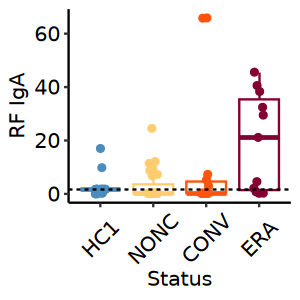

In [13]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5) # default 7x7

p <- plotBoxplot(meta_baseline, 'rfiga_result', 1.7, 'RF IgA')
p
ggsave(filename = file.path(fig_path, 'FigS1C_top_RFIgA.pdf'), 
       device = 'pdf', 
       width = 2.5, 
       height = 2.5, 
       units = 'in')

In [14]:
kruskal.test(rfiga_result ~ Status, 
             data = meta_baseline)


	Kruskal-Wallis rank sum test

data:  rfiga_result by Status
Kruskal-Wallis chi-squared = 12.616, df = 3, p-value = 0.005544


In [15]:
meta_baseline %>% dunn_test(rfiga_result~Status, 
          p.adjust.method  = 'BH')

,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rfiga_result,HC1,NONC,35,31,-1.8383544,0.0660101939,0.099015291,ns
2,rfiga_result,HC1,CONV,35,14,-0.7424667,0.4578046188,0.497185722,ns
3,rfiga_result,HC1,ERA,35,11,2.1994274,0.0278475452,0.055695090,ns
4,rfiga_result,NONC,CONV,31,14,0.6789245,0.4971857223,0.497185722,ns
5,rfiga_result,NONC,ERA,31,11,3.4581905,0.0005438168,0.003262901,**
6,rfiga_result,CONV,ERA,14,11,2.4696285,0.0135253449,0.040576035,*


In [16]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/seurat_v5/lib/libopenblasp-r0.3.24.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] rstatix_0.7.2   ggplot2_3.5.1   dunn.test_1.3.6 qvalue_2.34.0  
[5] dplyr_1.1.3     hise_2.16.0    

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        generics_0.1.3    tidyr_1.3.0       bitops_1.0-9     
 [5] stringi_1.8.1     digest_0.6.33     magrittr_2.0.3    evaluate_0.23    
 [9] gri